# 🏠 Airbnb Paris Regulation Impact Analysis

### 📊 Data Analyst Portfolio Project

**Tools:** Python, Pandas, Matplotlib, Seaborn  
**Dataset:** Airbnb listings in Paris  
**Main question:** How did the Paris Airbnb market change around the 2015 regulation period?

---

## 🎯 Project Goal

This project studies Airbnb listings in Paris.

The main goal is to understand how the market changed over time, especially around the **2015 regulation period**.

In this notebook, I analyze:

1. 🗺️ Price differences by neighbourhood  
2. 🏠 Price changes by guest capacity  
3. 📈 New host/listing growth over time  
4. ⚖️ Market changes before and after 2015  
5. 🦠 The effect of unusual COVID-19 years  

---


## 📌 Table of Contents

1. ⚙️ **Setup**  
   Import Python libraries and set display options.

2. 📥 **Load the Data**  
   Read the Airbnb listings dataset.

3. 🧹 **Prepare the Paris Dataset**  
   Select Paris listings and clean important columns.

4. ✅ **Data Quality Checks**  
   Check missing values, invalid prices, and invalid capacity values.

5. 📊 **Create Summary Tables**  
   Build tables for neighbourhood prices, capacity prices, and yearly trends.

6. 📈 **Visualize the Data**  
   Create charts to understand price and market patterns.

7. ⚖️ **Extra Analysis: Before vs After 2015**  
   Study market growth and price trends around the 2015 regulation period.


# 1. Setup

**Goal:** Import the libraries and set simple display options.

We use:

- `pandas` for data work
- `numpy` for numeric work
- `matplotlib` for charts
- `seaborn` only for a cleaner chart style


In [1]:
# Core libraries
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional style library
try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except ImportError:
    sns = None

# Display settings
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", "{:.2f}".format)

# Plot settings
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["figure.dpi"] = 120


# 2. Load the Data

**Goal:** Read the `listings.csv` file.

> Note: Some CSV files have encoding issues.  
> This notebook uses `encoding="iso-8859-1"` because it is safer for this dataset.


In [2]:
DATA_PATH = Path("listings.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "The file 'listings.csv' was not found. "
        "Please place it in the same folder as this notebook."
    )

listings = pd.read_csv(
    DATA_PATH,
    encoding="iso-8859-1",
    low_memory=False
)

print(f"Rows: {listings.shape[0]:,}")
print(f"Columns: {listings.shape[1]:,}")

display(listings.head())


Rows: 279,712
Columns: 33


,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,district,city,latitude,longitude,property_type,room_type,accommodates,bedrooms,amenities,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.00,t,f,Buttes-Montmartre,NaN,Paris,48.89,2.33,Entire apartment,Entire place,2,1.00,"[""Heating"", ""Kitchen"", ""Washer"", ""Wifi"", ""Long...",53,2,1125,100.00,10.00,10.00,10.00,10.00,10.00,10.00,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.00,t,t,Buttes-Montmartre,NaN,Paris,48.89,2.35,Entire apartment,Entire place,2,1.00,"[""Shampoo"", ""Heating"", ""Kitchen"", ""Essentials""...",120,2,1125,100.00,10.00,10.00,10.00,10.00,10.00,10.00,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.00,t,f,Elysee,NaN,Paris,48.88,2.32,Entire apartment,Entire place,2,1.00,"[""Heating"", ""TV"", ""Kitchen"", ""Washer"", ""Wifi"",...",89,2,1125,100.00,10.00,10.00,10.00,10.00,10.00,10.00,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.00,t,t,Vaugirard,NaN,Paris,48.85,2.31,Entire apartment,Entire place,2,1.00,"[""Heating"", ""TV"", ""Kitchen"", ""Wifi"", ""Long ter...",58,2,1125,100.00,10.00,10.00,10.00,10.00,10.00,10.00,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.00,t,f,Passy,NaN,Paris,48.85,2.27,Entire apartment,Entire place,2,1.00,"[""Heating"", ""TV"", ""Kitchen"", ""Essentials"", ""Ha...",60,2,1125,100.00,10.00,10.00,10.00,10.00,10.00,10.00,f


### Quick Structure Check

**Goal:** Check column names, data types, and missing values.


In [3]:
listings.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   listing_id                   279712 non-null  int64  
 1   name                         279537 non-null  object 
 2   host_id                      279712 non-null  int64  
 3   host_since                   279547 non-null  object 
 4   host_location                278872 non-null  object 
 5   host_response_time           150930 non-null  object 
 6   host_response_rate           150930 non-null  float64
 7   host_acceptance_rate         166625 non-null  float64
 8   host_is_superhost            279547 non-null  object 
 9   host_total_listings_count    279547 non-null  float64
 10  host_has_profile_pic         279547 non-null  object 
 11  host_identity_verified       279547 non-null  object 
 12  neighbourhood                279712 non-null  object 
 13 

# 3. Prepare the Paris Dataset

**Goal:** Create a clean Paris-only dataset.

We will:

1. Check the needed columns
2. Convert `host_since` to a date
3. Clean the `price` column if needed
4. Filter only Paris rows
5. Keep only the columns used in this project


In [4]:
required_columns = ["host_since", "neighbourhood", "city", "accommodates", "price"]

missing_columns = [col for col in required_columns if col not in listings.columns]

if missing_columns:
    raise ValueError(f"Missing columns in the dataset: {missing_columns}")

print("All required columns are available.")


All required columns are available.


In [5]:
# Convert host_since to datetime.
# errors="coerce" turns bad dates into NaT instead of stopping the notebook.
listings["host_since"] = pd.to_datetime(listings["host_since"], errors="coerce")

# Clean price if it is saved as text, for example "$120.00".
if not pd.api.types.is_numeric_dtype(listings["price"]):
    listings["price"] = (
        listings["price"]
        .astype(str)
        .str.replace(r"[$,]", "", regex=True)
        .replace("nan", np.nan)
        .astype(float)
    )

# Make sure accommodates is numeric.
listings["accommodates"] = pd.to_numeric(listings["accommodates"], errors="coerce")


In [6]:
paris_listings = (
    listings
    .query("city == 'Paris'")
    .loc[:, ["host_since", "neighbourhood", "city", "accommodates", "price"]]
    .copy()
)

print(f"Paris listings: {len(paris_listings):,}")
display(paris_listings.head())


Paris listings: 64,690


,host_since,neighbourhood,city,accommodates,price
0,2011-12-03,Buttes-Montmartre,Paris,2,53
1,2013-11-29,Buttes-Montmartre,Paris,2,120
2,2014-07-31,Elysee,Paris,2,89
3,2013-12-17,Vaugirard,Paris,2,58
4,2014-12-14,Passy,Paris,2,60


# 4. Data Quality Checks

**Goal:** Understand data quality before building charts.

We check:

- Missing values
- Basic numeric summary
- Invalid values such as `price == 0` or `accommodates == 0`


In [7]:
missing_summary = (
    paris_listings
    .isna()
    .sum()
    .to_frame("missing_count")
)

missing_summary["missing_percent"] = (
    missing_summary["missing_count"] / len(paris_listings) * 100
).round(2)

display(missing_summary)


,missing_count,missing_percent
host_since,33,0.05
neighbourhood,0,0.00
city,0,0.00
accommodates,0,0.00
price,0,0.00


In [8]:
display(paris_listings[["accommodates", "price"]].describe())


,accommodates,price
count,64690.00,64690.00
mean,3.04,113.10
std,1.59,214.43
min,0.00,0.00
25%,2.00,59.00
50%,2.00,80.00
75%,4.00,120.00
max,16.00,12000.00


In [9]:
invalid_checks = pd.DataFrame({
    "check": [
        "accommodates == 0",
        "price == 0",
        "accommodates > 0 and price == 0",
        "missing host_since"
    ],
    "row_count": [
        (paris_listings["accommodates"] == 0).sum(),
        (paris_listings["price"] == 0).sum(),
        ((paris_listings["accommodates"] > 0) & (paris_listings["price"] == 0)).sum(),
        paris_listings["host_since"].isna().sum()
    ]
})

display(invalid_checks)


,check,row_count
0,accommodates == 0,54
1,price == 0,62
2,accommodates > 0 and price == 0,8
3,missing host_since,33


### Analysis Dataset

For the charts, we remove rows where:

- `price <= 0`
- `accommodates <= 0`

This is a simple cleaning step. It keeps the analysis easier to explain.


In [10]:
paris_clean = (
    paris_listings
    .query("price > 0 and accommodates > 0")
    .dropna(subset=["neighbourhood"])
    .copy()
)

print(f"Rows before cleaning: {len(paris_listings):,}")
print(f"Rows after cleaning:  {len(paris_clean):,}")
print(f"Rows removed:         {len(paris_listings) - len(paris_clean):,}")


Rows before cleaning: 64,690
Rows after cleaning:  64,628
Rows removed:         62


# 5. Create Summary Tables

**Goal:** Create clean tables for the visualizations.

We will create three tables:

1. Average price by neighbourhood
2. Average price by guest capacity in the most expensive neighbourhood
3. Yearly new hosts and average price


### 5.1 Average Price by Neighbourhood

**Question:** Which Paris neighbourhoods are cheaper or more expensive?


In [11]:
paris_price_by_neighbourhood = (
    paris_clean
    .groupby("neighbourhood", as_index=False)
    .agg(
        avg_price=("price", "mean"),
        listing_count=("price", "size")
    )
    .sort_values("avg_price", ascending=True)
)

display(paris_price_by_neighbourhood.head(10))
display(paris_price_by_neighbourhood.tail(10))


,neighbourhood,avg_price,listing_count
10,Menilmontant,74.96,3757
2,Buttes-Chaumont,82.69,3728
3,Buttes-Montmartre,87.23,7235
17,Reuilly,89.13,2652
16,Popincourt,90.59,6204
6,Gobelins,98.11,2278
11,Observatoire,101.99,2482
0,Batignolles-Monceau,102.68,4327
5,Enclos-St-Laurent,103.10,4622
19,Vaugirard,107.08,4815


,neighbourhood,avg_price,listing_count
12,Opera,119.19,3153
14,Pantheon,122.95,2135
18,Temple,138.45,2943
7,Hotel-de-Ville,144.47,1972
1,Bourse,149.63,2186
9,Luxembourg,155.79,1996
13,Palais-Bourbon,157.48,1764
15,Passy,161.24,3213
8,Louvre,175.75,1405
4,Elysee,211.37,1761


In [12]:
most_expensive_neighbourhood = (
    paris_price_by_neighbourhood
    .sort_values("avg_price", ascending=False)
    .iloc[0]["neighbourhood"]
)

print(f"Most expensive neighbourhood: {most_expensive_neighbourhood}")


Most expensive neighbourhood: Elysee


### 5.2 Price by Guest Capacity

**Question:** In the most expensive neighbourhood, do bigger listings cost more?

We also keep `listing_count`.  
This helps us see when a group has only a few listings.


In [13]:
price_by_accommodates = (
    paris_clean
    .query("neighbourhood == @most_expensive_neighbourhood")
    .groupby("accommodates", as_index=False)
    .agg(
        avg_price=("price", "mean"),
        median_price=("price", "median"),
        listing_count=("price", "size")
    )
    .sort_values("accommodates", ascending=True)
)

display(price_by_accommodates)


,accommodates,avg_price,median_price,listing_count
0,1,79.52,52.50,90
1,2,155.10,95.50,716
2,3,153.88,110.00,145
3,4,212.10,150.00,458
4,5,328.82,232.00,82
5,6,355.51,259.00,175
6,7,411.54,235.50,26
7,8,405.52,363.00,27
8,9,440.27,416.00,11
9,10,500.86,454.50,14


### 5.3 Yearly New Hosts and Average Price

**Question:** How did the market change over time?

`new_hosts` is a simple proxy.  
It counts listings by the year of `host_since`.


In [14]:
paris_yearly_trends = (
    paris_clean
    .dropna(subset=["host_since"])
    .assign(year=lambda df: df["host_since"].dt.year)
    .groupby("year", as_index=False)
    .agg(
        new_hosts=("host_since", "size"),
        avg_price=("price", "mean"),
        median_price=("price", "median")
    )
    .sort_values("year")
)

display(paris_yearly_trends.head())
display(paris_yearly_trends.tail())


,year,new_hosts,avg_price,median_price
0,2008,4,77.75,70.00
1,2009,106,159.64,110.00
2,2010,416,125.03,100.00
3,2011,1339,124.83,90.00
4,2012,4592,111.58,86.00


,year,new_hosts,avg_price,median_price
9,2017,4585,108.66,79.00
10,2018,4294,138.21,90.00
11,2019,5685,129.96,90.00
12,2020,3363,143.52,89.00
13,2021,133,93.49,59.00


# 6. Visualize the Data

**Goal:** Build clear charts with simple titles and labels.

Good charts should be easy to read without extra explanation.


### 6.1 Average Price by Neighbourhood


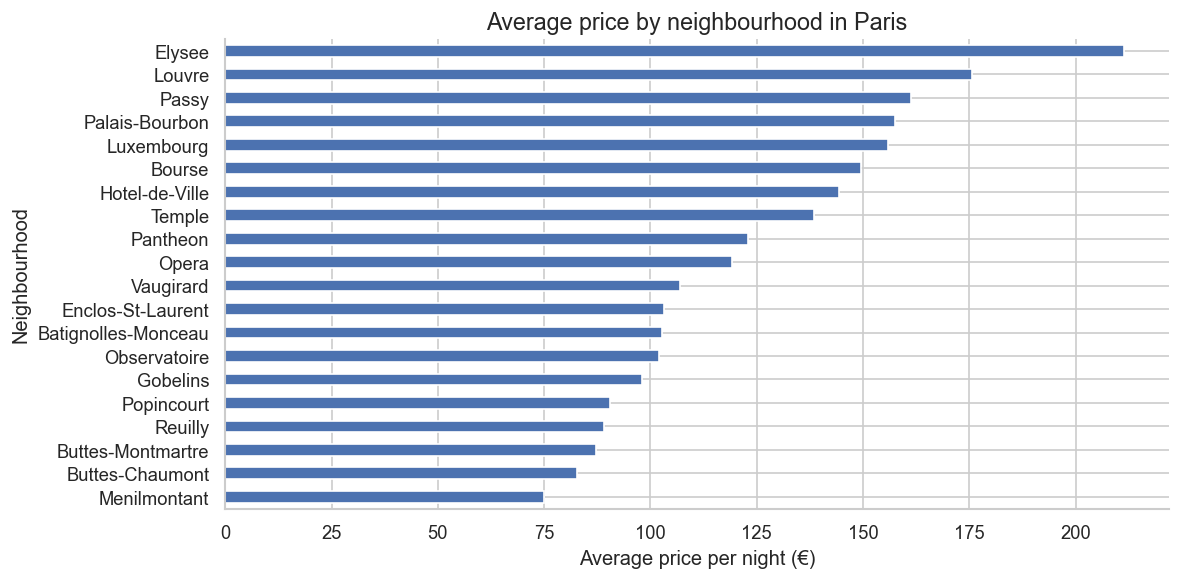

In [15]:
plot_data = paris_price_by_neighbourhood.sort_values("avg_price", ascending=True)

ax = plot_data.plot(
    x="neighbourhood",
    y="avg_price",
    kind="barh",
    legend=False,
    title="Average price by neighbourhood in Paris"
)

ax.set_xlabel("Average price per night (€)")
ax.set_ylabel("Neighbourhood")

if sns:
    sns.despine()

plt.tight_layout()
plt.show()


### 6.2 Price by Guest Capacity

This chart uses the most expensive neighbourhood only.


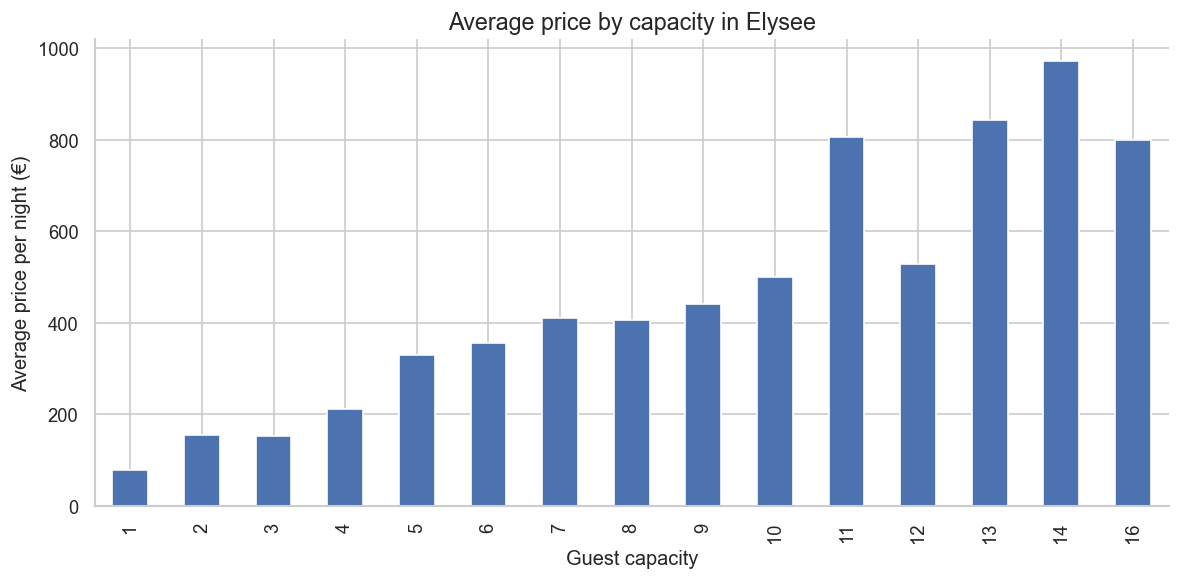

In [16]:
plot_data = price_by_accommodates.copy()

ax = plot_data.plot(
    x="accommodates",
    y="avg_price",
    kind="bar",
    legend=False,
    title=f"Average price by capacity in {most_expensive_neighbourhood}"
)

ax.set_xlabel("Guest capacity")
ax.set_ylabel("Average price per night (€)")

if sns:
    sns.despine()

plt.tight_layout()
plt.show()


### 6.3 New Hosts Over Time

The dashed line marks 2015.  
This helps us compare the period before and after regulation.


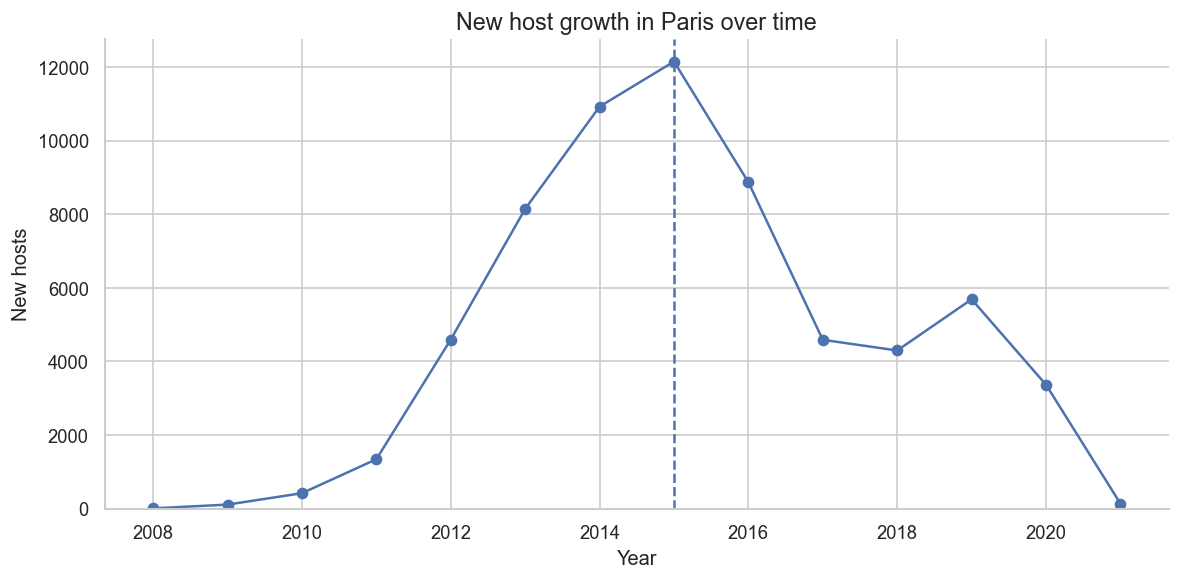

In [17]:
ax = paris_yearly_trends.plot(
    x="year",
    y="new_hosts",
    kind="line",
    marker="o",
    legend=False,
    title="New host growth in Paris over time"
)

ax.axvline(2015, linestyle="--")
ax.set_xlabel("Year")
ax.set_ylabel("New hosts")
ax.set_ylim(bottom=0)

if sns:
    sns.despine()

plt.tight_layout()
plt.show()


### 6.4 Average Price Over Time


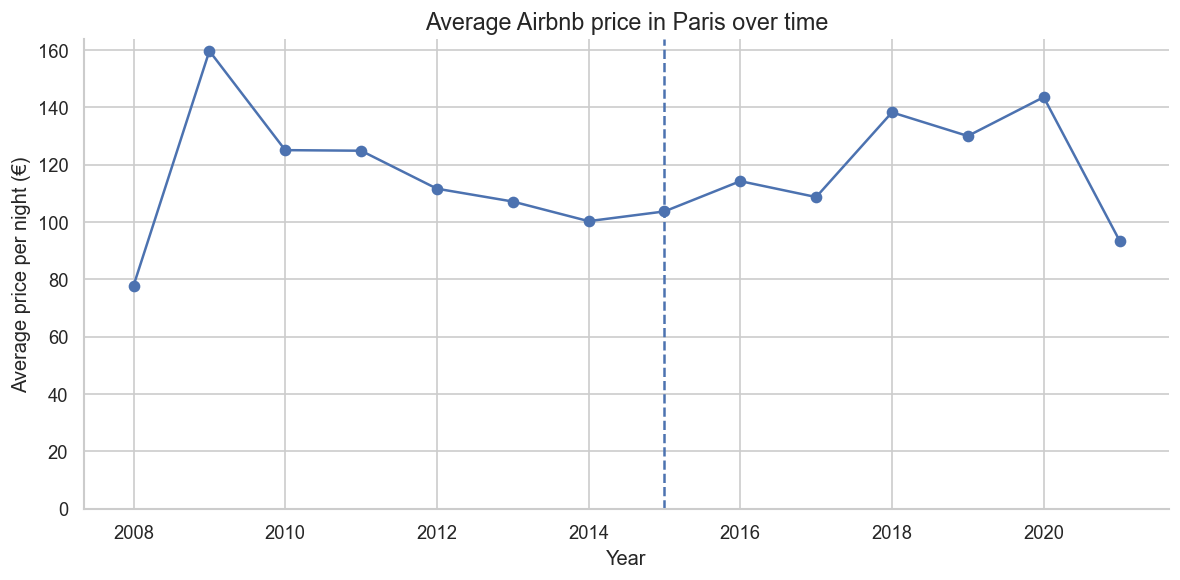

In [18]:
ax = paris_yearly_trends.plot(
    x="year",
    y="avg_price",
    kind="line",
    marker="o",
    legend=False,
    title="Average Airbnb price in Paris over time"
)

ax.axvline(2015, linestyle="--")
ax.set_xlabel("Year")
ax.set_ylabel("Average price per night (€)")
ax.set_ylim(bottom=0)

if sns:
    sns.despine()

plt.tight_layout()
plt.show()


### 6.5 Bonus Chart: New Hosts and Price Together

This chart shows both lines in one place.

- Left axis: new hosts
- Right axis: average price

This is useful for storytelling, but it should be read carefully because the axes are different.


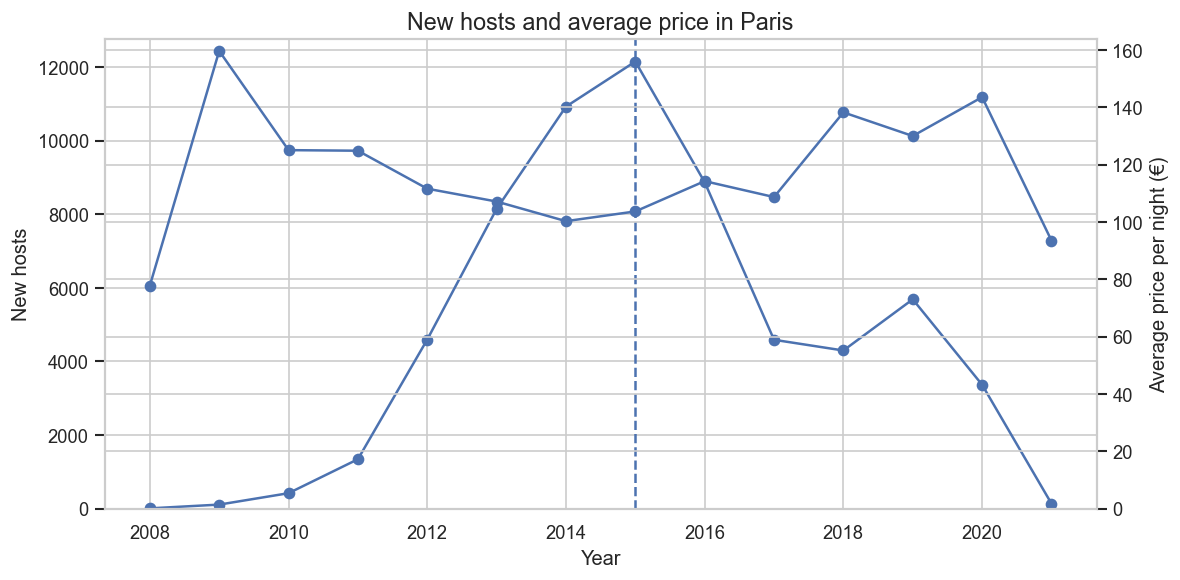

In [19]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    paris_yearly_trends["year"],
    paris_yearly_trends["new_hosts"],
    marker="o",
    label="New hosts"
)
ax1.set_xlabel("Year")
ax1.set_ylabel("New hosts")
ax1.set_ylim(bottom=0)
ax1.axvline(2015, linestyle="--")

ax2 = ax1.twinx()
ax2.plot(
    paris_yearly_trends["year"],
    paris_yearly_trends["avg_price"],
    marker="o",
    label="Average price (€)"
)
ax2.set_ylabel("Average price per night (€)")
ax2.set_ylim(bottom=0)

plt.title("New hosts and average price in Paris")
fig.tight_layout()
plt.show()


# 7. Extra Analysis: Market Changes Around 2015

**Important note:**  
This is a before-after analysis.  
It can show a change in the trend, but it does not prove that regulation caused the change.


## 7.1 Create the Analysis Dataset

In this section, we use yearly Airbnb trends from 2009 to 2021.

We use this data to check:

- Market growth around the 2015 peak
- Price movement around 2015
- The effect of COVID-19 years

The analysis is descriptive. It shows patterns, but it does not prove causation.


In [20]:
analysis_years = paris_yearly_trends.query("2009 <= year <= 2022").copy()

analysis_years["period"] = np.where(
    analysis_years["year"] <= 2014,
    "Before 2015",
    "After 2015"
)

display(analysis_years.head())
display(analysis_years.tail())


,year,new_hosts,avg_price,median_price,period
1,2009,106,159.64,110.00,Before 2015
2,2010,416,125.03,100.00,Before 2015
3,2011,1339,124.83,90.00,Before 2015
4,2012,4592,111.58,86.00,Before 2015
5,2013,8142,107.10,80.00,Before 2015


,year,new_hosts,avg_price,median_price,period
9,2017,4585,108.66,79.00,After 2015
10,2018,4294,138.21,90.00,After 2015
11,2019,5685,129.96,90.00,After 2015
12,2020,3363,143.52,89.00,After 2015
13,2021,133,93.49,59.00,After 2015


## 7.2 Market Growth Momentum After the 2015 Peak

The simple before-after average is not the best way to understand market growth.

Airbnb grew very fast before 2015.

Because of this, the after-2015 average can still look high even if growth slowed down.

So, in this section, we look at the market peak and the years after the peak.

This is a better way to answer the question:

Did new host growth slow down after 2015?

In [21]:
# 7.2 Market growth momentum after the 2015 peak

growth_momentum = (
    analysis_years
    [["year", "new_hosts"]]
    .copy()
    .sort_values("year")
)

# Year-over-year change
growth_momentum["change_from_previous_year"] = growth_momentum["new_hosts"].diff()

growth_momentum["change_from_previous_year_pct"] = (
    growth_momentum["new_hosts"].pct_change() * 100
).round(1)

# Find peak year
peak_year = growth_momentum.loc[growth_momentum["new_hosts"].idxmax(), "year"]
peak_new_hosts = growth_momentum.loc[growth_momentum["new_hosts"].idxmax(), "new_hosts"]

# Compare every year with the peak year
growth_momentum["change_from_peak_pct"] = (
    (growth_momentum["new_hosts"] - peak_new_hosts) / peak_new_hosts * 100
).round(1)

display(growth_momentum)

print("Market growth momentum result")
print("-----------------------------")
print(f"The peak year was {peak_year}, with {peak_new_hosts:,.0f} new hosts/listings.")
print()

# Show post-peak years before COVID
post_peak = growth_momentum.query("year > @peak_year and year <= 2019").copy()

for _, row in post_peak.iterrows():
    print(
        f"In {int(row['year'])}, new hosts/listings were {row['new_hosts']:,.0f}. "
        f"This was {row['change_from_peak_pct']:.1f}% lower than the 2015 peak."
    )

print()
print("Interpretation:")
print("New host/listing growth reached its highest point in 2015.")
print("After 2015, the number of new hosts/listings dropped strongly from the peak.")
print("This shows a slowdown in market growth after 2015.")

,year,new_hosts,change_from_previous_year,change_from_previous_year_pct,change_from_peak_pct
1,2009,106,NaN,NaN,-99.10
2,2010,416,310.00,292.50,-96.60
3,2011,1339,923.00,221.90,-89.00
4,2012,4592,3253.00,242.90,-62.20
5,2013,8142,3550.00,77.30,-33.00
6,2014,10922,2780.00,34.10,-10.10
7,2015,12147,1225.00,11.20,0.00
8,2016,8867,-3280.00,-27.00,-27.00
9,2017,4585,-4282.00,-48.30,-62.30
10,2018,4294,-291.00,-6.30,-64.60


Market growth momentum result
-----------------------------
The peak year was 2015, with 12,147 new hosts/listings.

In 2016, new hosts/listings were 8,867. This was -27.0% lower than the 2015 peak.
In 2017, new hosts/listings were 4,585. This was -62.3% lower than the 2015 peak.
In 2018, new hosts/listings were 4,294. This was -64.6% lower than the 2015 peak.
In 2019, new hosts/listings were 5,685. This was -53.2% lower than the 2015 peak.

Interpretation:
New host/listing growth reached its highest point in 2015.
After 2015, the number of new hosts/listings dropped strongly from the peak.
This shows a slowdown in market growth after 2015.


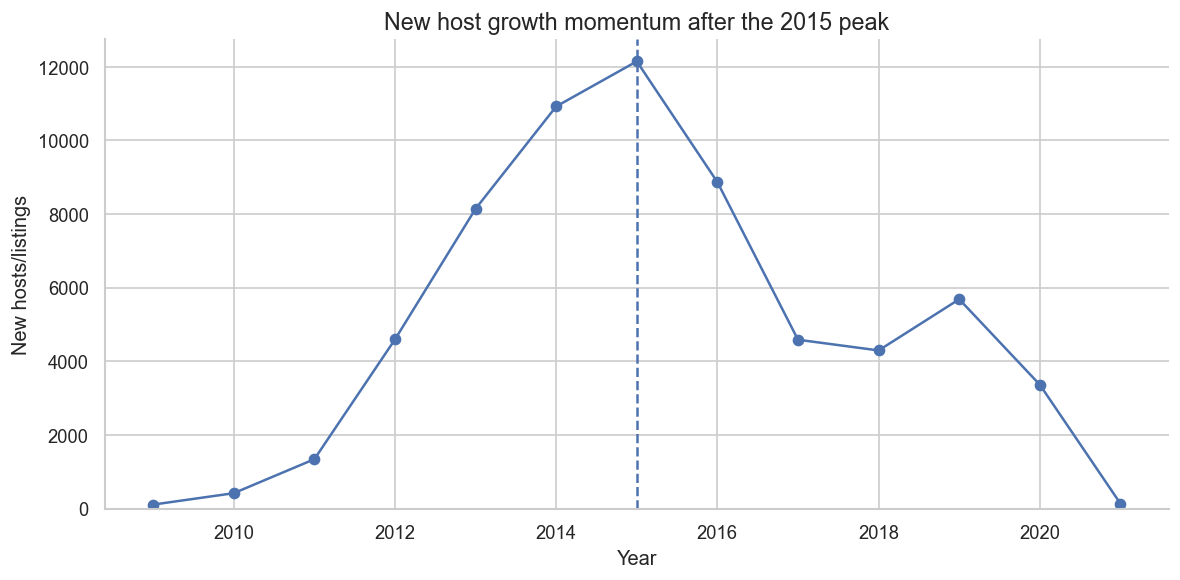

In [22]:
ax = growth_momentum.plot(
    x="year",
    y="new_hosts",
    kind="line",
    marker="o",
    legend=False,
    title="New host growth momentum after the 2015 peak"
)

ax.axvline(2015, linestyle="--")

ax.set_xlabel("Year")
ax.set_ylabel("New hosts/listings")
ax.set_ylim(bottom=0)

if sns:
    sns.despine()

plt.tight_layout()
plt.show()

## 7.3 Price Trend Around 2015

The simple before-after average can be misleading for price.

It compares two large periods, but it does not show the direction of the trend.

For price, the line chart is more useful.

In this section, we check two direct changes:

1. Price change from 2009 to 2014
2. Price change from 2015 to 2020

We do not use 2021 for the main post-2015 price trend because it has very few listings and can be affected by COVID-19.

In [23]:
# 7.3 Price Trend Around 2015

price_trend_points = (
    paris_yearly_trends
    .query("year in [2009, 2014, 2015, 2020, 2021]")
    [["year", "new_hosts", "avg_price", "median_price"]]
    .copy()
)

display(price_trend_points)

price_2009 = price_trend_points.query("year == 2009").iloc[0]
price_2014 = price_trend_points.query("year == 2014").iloc[0]
price_2015 = price_trend_points.query("year == 2015").iloc[0]
price_2020 = price_trend_points.query("year == 2020").iloc[0]
price_2021 = price_trend_points.query("year == 2021").iloc[0]

pre_2015_price_change = (
    (price_2014["avg_price"] - price_2009["avg_price"])
    / price_2009["avg_price"]
    * 100
)

post_2015_price_change = (
    (price_2020["avg_price"] - price_2015["avg_price"])
    / price_2015["avg_price"]
    * 100
)

post_2021_drop = (
    (price_2021["avg_price"] - price_2020["avg_price"])
    / price_2020["avg_price"]
    * 100
)

print("Price trend checks")
print("------------------")

print(
    f"From 2009 to 2014, average price changed from "
    f"€{price_2009['avg_price']:.2f} to €{price_2014['avg_price']:.2f} "
    f"({pre_2015_price_change:.1f}%)."
)

print(
    f"From 2015 to 2020, average price changed from "
    f"€{price_2015['avg_price']:.2f} to €{price_2020['avg_price']:.2f} "
    f"({post_2015_price_change:.1f}%)."
)

print(
    f"From 2020 to 2021, average price changed from "
    f"€{price_2020['avg_price']:.2f} to €{price_2021['avg_price']:.2f} "
    f"({post_2021_drop:.1f}%)."
)

print()
print("Interpretation:")
print("Prices decreased before 2015, then increased from 2015 to 2020.")
print("The 2021 value is lower and should be read carefully.")

,year,new_hosts,avg_price,median_price
1,2009,106,159.64,110.00
6,2014,10922,100.25,79.00
7,2015,12147,103.65,75.00
12,2020,3363,143.52,89.00
13,2021,133,93.49,59.00


Price trend checks
------------------
From 2009 to 2014, average price changed from €159.64 to €100.25 (-37.2%).
From 2015 to 2020, average price changed from €103.65 to €143.52 (38.5%).
From 2020 to 2021, average price changed from €143.52 to €93.49 (-34.9%).

Interpretation:
Prices decreased before 2015, then increased from 2015 to 2020.
The 2021 value is lower and should be read carefully.


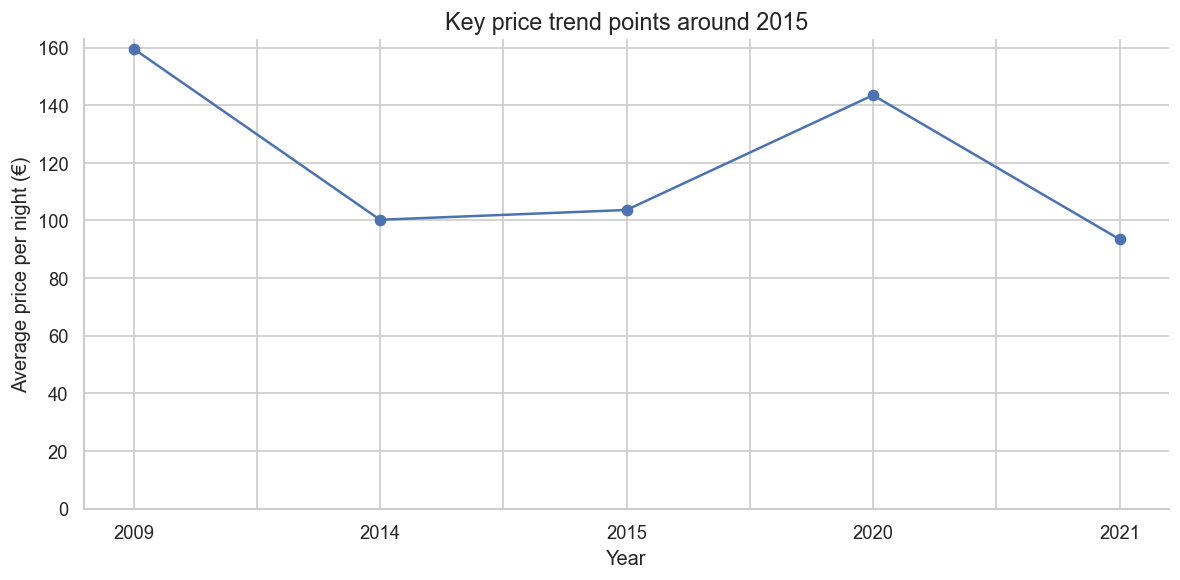

In [24]:
# 7.3 Price trend points chart

trend_points_for_plot = pd.DataFrame({
    "period": [
        "2009",
        "2014",
        "2015",
        "2020",
        "2021"
    ],
    "avg_price": [
        price_2009["avg_price"],
        price_2014["avg_price"],
        price_2015["avg_price"],
        price_2020["avg_price"],
        price_2021["avg_price"]
    ]
})

ax = trend_points_for_plot.plot(
    x="period",
    y="avg_price",
    kind="line",
    marker="o",
    legend=False,
    title="Key price trend points around 2015"
)

ax.set_xlabel("Year")
ax.set_ylabel("Average price per night (€)")
ax.set_ylim(bottom=0)

if sns:
    sns.despine()

plt.tight_layout()
plt.show()

## 7.4 Pandemic Sensitivity Check

The years 2020 and 2021 may be unusual because of COVID-19.

For this reason, we remove 2020 and 2021 and check the trend again.

This helps us understand if the main pattern is only caused by the pandemic years or not.

We check two things:

1. New host/listing growth after the 2015 peak
2. Average price trend after 2015

In [25]:
# 7.4 Pandemic sensitivity check

no_covid_years = (
    analysis_years
    .query("year not in [2020, 2021]")
    .copy()
    .sort_values("year")
)

display(no_covid_years)

# Find the peak year without COVID years
peak_year_no_covid = no_covid_years.loc[
    no_covid_years["new_hosts"].idxmax(),
    "year"
]

peak_hosts_no_covid = no_covid_years.loc[
    no_covid_years["new_hosts"].idxmax(),
    "new_hosts"
]

# Check post-peak years
post_peak_no_covid = (
    no_covid_years
    .query("year > @peak_year_no_covid")
    [["year", "new_hosts", "avg_price", "median_price"]]
    .copy()
)

post_peak_no_covid["change_from_peak_pct"] = (
    (post_peak_no_covid["new_hosts"] - peak_hosts_no_covid)
    / peak_hosts_no_covid
    * 100
).round(1)

display(post_peak_no_covid)

# Price change from 2015 to 2019
price_2015_no_covid = no_covid_years.query("year == 2015")["avg_price"].iloc[0]
price_2019_no_covid = no_covid_years.query("year == 2019")["avg_price"].iloc[0]

price_change_2015_2019 = (
    (price_2019_no_covid - price_2015_no_covid)
    / price_2015_no_covid
    * 100
)

print("Pandemic sensitivity check")
print("--------------------------")
print(f"After removing 2020 and 2021, the peak year is still {int(peak_year_no_covid)}.")
print(f"The peak had {peak_hosts_no_covid:,.0f} new hosts/listings.")
print()

for _, row in post_peak_no_covid.iterrows():
    print(
        f"In {int(row['year'])}, new hosts/listings were {row['new_hosts']:,.0f}. "
        f"This was {row['change_from_peak_pct']:.1f}% lower than the peak."
    )

print()
print(
    f"Average price changed from €{price_2015_no_covid:.2f} in 2015 "
    f"to €{price_2019_no_covid:.2f} in 2019 "
    f"({price_change_2015_2019:.1f}%)."
)

print()
print("Interpretation:")
print("Even after removing 2020 and 2021, 2015 is still the peak year.")
print("New host/listing growth slowed after 2015.")
print("Average price increased from 2015 to 2019.")

,year,new_hosts,avg_price,median_price,period
1,2009,106,159.64,110.00,Before 2015
2,2010,416,125.03,100.00,Before 2015
3,2011,1339,124.83,90.00,Before 2015
4,2012,4592,111.58,86.00,Before 2015
5,2013,8142,107.10,80.00,Before 2015
6,2014,10922,100.25,79.00,Before 2015
7,2015,12147,103.65,75.00,After 2015
8,2016,8867,114.21,76.00,After 2015
9,2017,4585,108.66,79.00,After 2015
10,2018,4294,138.21,90.00,After 2015


,year,new_hosts,avg_price,median_price,change_from_peak_pct
8,2016,8867,114.21,76.00,-27.00
9,2017,4585,108.66,79.00,-62.30
10,2018,4294,138.21,90.00,-64.60
11,2019,5685,129.96,90.00,-53.20


Pandemic sensitivity check
--------------------------
After removing 2020 and 2021, the peak year is still 2015.
The peak had 12,147 new hosts/listings.

In 2016, new hosts/listings were 8,867. This was -27.0% lower than the peak.
In 2017, new hosts/listings were 4,585. This was -62.3% lower than the peak.
In 2018, new hosts/listings were 4,294. This was -64.6% lower than the peak.
In 2019, new hosts/listings were 5,685. This was -53.2% lower than the peak.

Average price changed from €103.65 in 2015 to €129.96 in 2019 (25.4%).

Interpretation:
Even after removing 2020 and 2021, 2015 is still the peak year.
New host/listing growth slowed after 2015.
Average price increased from 2015 to 2019.


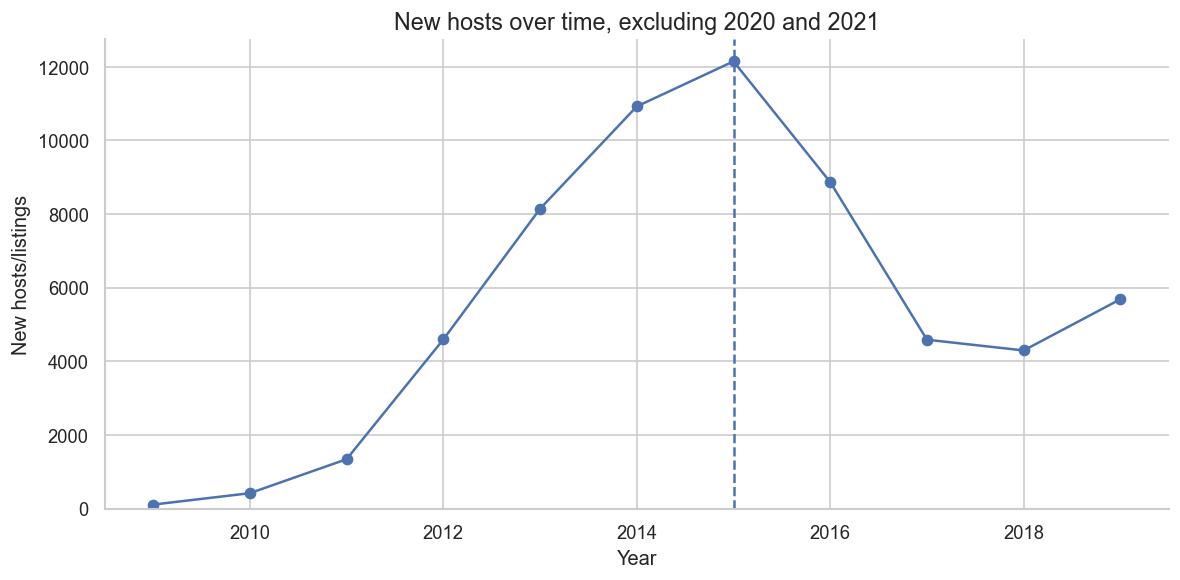

In [26]:
# New hosts trend excluding 2020 and 2021

ax = no_covid_years.plot(
    x="year",
    y="new_hosts",
    kind="line",
    marker="o",
    legend=False,
    title="New hosts over time, excluding 2020 and 2021"
)

ax.axvline(2015, linestyle="--")

ax.set_xlabel("Year")
ax.set_ylabel("New hosts/listings")
ax.set_ylim(bottom=0)

if sns:
    sns.despine()

plt.tight_layout()
plt.show()

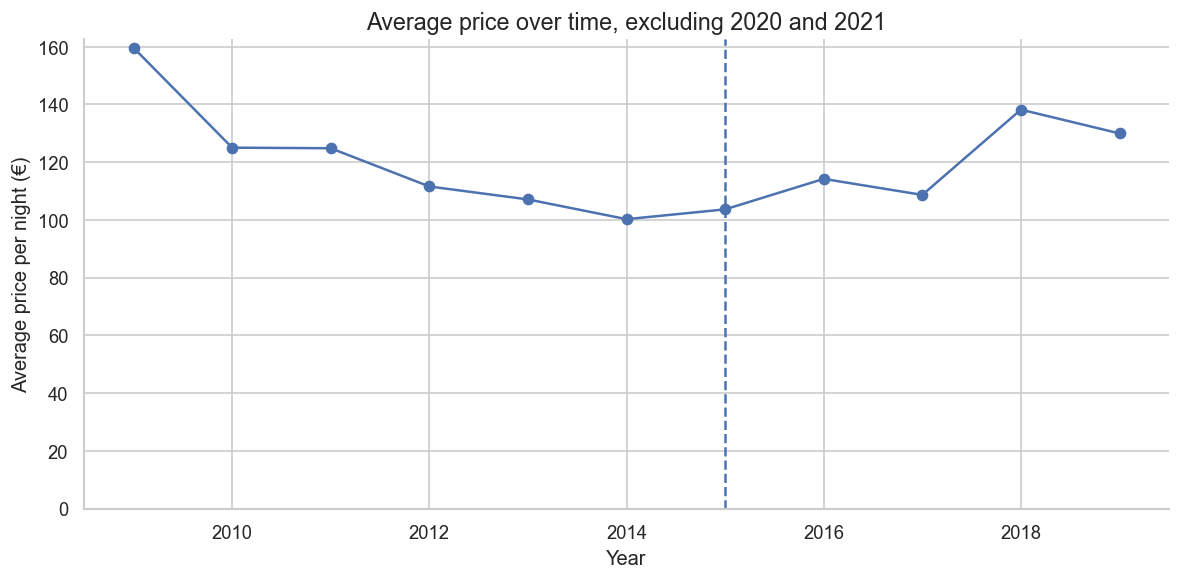

In [27]:
# Average price trend excluding 2020 and 2021

ax = no_covid_years.plot(
    x="year",
    y="avg_price",
    kind="line",
    marker="o",
    legend=False,
    title="Average price over time, excluding 2020 and 2021"
)

ax.axvline(2015, linestyle="--")

ax.set_xlabel("Year")
ax.set_ylabel("Average price per night (€)")
ax.set_ylim(bottom=0)

if sns:
    sns.despine()

plt.tight_layout()
plt.show()

## Notes

This notebook is ready for a data analyst portfolio.

Before uploading to GitHub:

1. Add the `listings.csv` file or explain where to download it.
2. Restart the kernel and run all cells from top to bottom.
3. Save the notebook with outputs if you want GitHub visitors to see the charts.
4. Add a short `README.md` with the project goal, tools, and main findings.
